# Notebook to explore photocentre movements

For paper3. To extract statistics on how the photocentre of an AGB star moves depending
on amount of dust in front of it in images, and for adapting and exploring GAIA data on
AGB stars. To extract photocentre movements of GAIA data.

## Extract Image photocentre

Inspired by the work by Beguin et al 2023 and 2024. Coords of photocentre is an
intensity weighted mean of the xy-positions of all emitting pixels in the image.
Formalised as

  Px = sum_x( sum_y( Image(x,y) * xcoord(x,y))) / sum_x( sum_y( Image(x,y) ))
  Px = sum_x( sum_y( Image(x,y) * ycoord(x,y))) / sum_x( sum_y( Image(x,y) ))

where Image(x,y) are all the pixel fluxes of the image and xcoord and ycoord are all
physical coordinates of the pixels of the images.


-0.07691745881662257 0.1991613097754044
-0.046616641707043986 0.1207038241063057


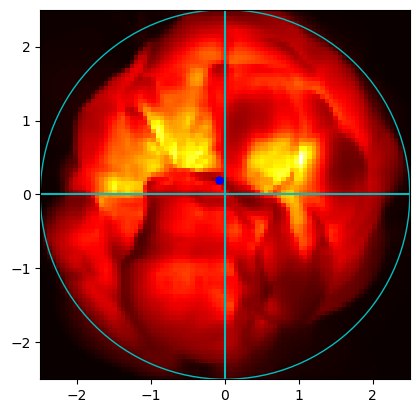

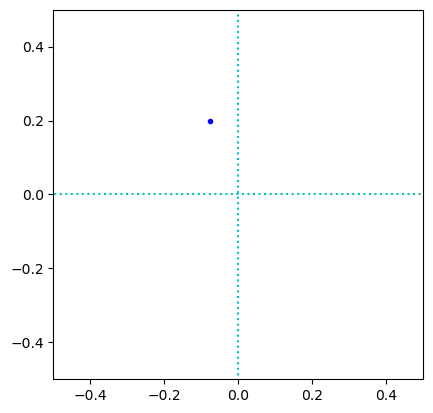

In [ ]:
# Test with only one snapshot and one image
import analyze_r3d_functions as a3d
import matplotlib.pyplot as plt
import numpy as np

modelname = 'st28gm06n052_timedep_nodust'
snapshot = '250'
angle = 'i000_phi000'
wavelength = '02'
beamradius = 2.5
# Gaia beam size at 2um is between 1.01 and 0.34 asec
# at 100pc : 101 to 34 au. So the 30x30 image size is not bad to use

image2d,image2dlog,totalflux,axisplot = a3d.load_images(
    path=f'../r3dresults/{modelname}/{snapshot}/',
    image=f'image_{angle}_{wavelength}um.out',
    distance=1
)
# Testplot just to see
plt.figure(1)
plt.imshow(
    image2d, origin='lower', extent=axisplot, cmap=plt.get_cmap('hot')
)
# Compute photocentreposition
# Uses Eqs 6 and 7 from Beguin+2024
(Nx,Ny) = np.shape(image2d)
xrange = np.linspace(axisplot[0],axisplot[1],Nx)
yrange = np.linspace(axisplot[2],axisplot[3],Ny)


nominatorX = 0
nominatorY = 0

demoninator = 0

for nx in range(Nx):
    for ny in range(Ny):
        if np.sqrt(xrange[nx]**2 + yrange[ny]**2) < beamradius:
            
            # Xcoord-sums
            nominatorX += image2d[ny,nx] * xrange[nx]

            # Ycoord-sums
            nominatorY += image2d[ny,nx] * yrange[ny]

            # Common demoninator
            demoninator += image2d[ny,nx]


Px = nominatorX/demoninator
Py = nominatorY/demoninator

print(Px,Py)
print(Px/1.65,Py/1.65)

# Plot to check
plt.plot([-4,4],[0,0],'c-')
plt.plot([0,0],[-4,4],'c-')
plotbeam = plt.Circle((0,0),beamradius,color='c',fill=False)
plt.plot(Px,Py,'b.',markersize=10)
plt.ylim(-2.5,2.5);
plt.xlim(-2.5,2.5);
plt.gca().add_patch(plotbeam)

# Plot only coordinate, close-up
fig,ax = plt.figure(2), plt.axes()
ax.plot(Px,Py,'b.')
ax.plot([-4,4],[0,0],'c:')
ax.plot([0,0],[-4,4],'c:')
ax.set_ylim(-0.5,0.5);
ax.set_xlim(-0.5,0.5);
ax.set_aspect('equal', 'box')

In [1]:
# Scan and write new dat-files with photocentre-displacements
#
# TODO
# do this with all 0.62um images when they are done!
# and for all snapshots
# for all three models

import analyze_r3d_functions as a3d

modelnames = [
    'st28gm06n052_timedep_nodust',
    'st28gm06n052_timedep_nospikes',
    'st28gm06n074_nodust',
    'st28gm06n074_nospikes',
    'st28gm06n075_nodust',
    'st28gm06n075_nospikes',
]

for modelname in modelnames:
    a3d.write_photocentre_files(
        model_path=f'../r3dresults/{modelname}/',
        wavelength='02',
        angles = [
            'i000_phi000',
            'i090_phi000',
            'i090_phi090',
            'i090_phi270',
            'i180_phi000',
            'i270_phi000',
        ],
        beam_size=2.5
    )


Running: write_photocentre_files
  Writing photocentre file
  At snapshot 100
  At snapshot 200
  At snapshot 300
Done!
Running: write_photocentre_files
  Writing photocentre file
  At snapshot 100
  At snapshot 200
  At snapshot 300
Done!
Running: write_photocentre_files
  Writing photocentre file
  At snapshot 100
  At snapshot 200
  At snapshot 300
Done!
Running: write_photocentre_files
  Writing photocentre file
  At snapshot 100
  At snapshot 200
  At snapshot 300
Done!
Running: write_photocentre_files
  Writing photocentre file
  At snapshot 100
  At snapshot 200
  At snapshot 300
Done!
Running: write_photocentre_files
  Writing photocentre file
  At snapshot 100
  At snapshot 200
  At snapshot 300
Done!


In [ ]:
# Check so that pcR movements are the same for the star for
# all three models


# TODO


Average for all nodust
  Average pcR : 0.08991686993776778 +/- 0.04596521933877597 Rstar

Average for all with dust
  Average pcR - st28gm06n052 : 0.22849858333333334 +/- 0.2248637429487968 Rstar
  Average pcR - st28gm06n074 : 0.15280743434343436 +/- 0.1560017589902236 Rstar
  Average pcR - st28gm06n075 : 0.09878965674848028 +/- 0.058942578989222234 Rstar


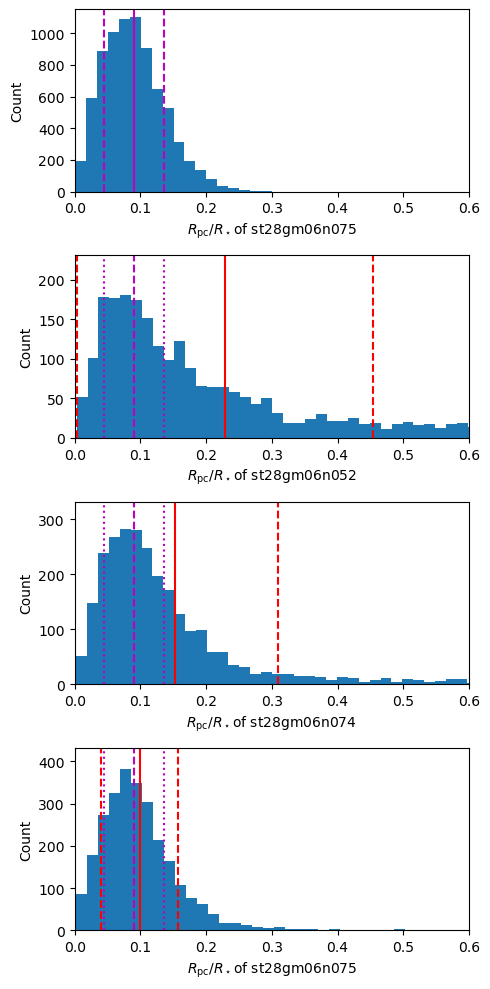

In [17]:
# Load all LOS and 3 nodust-models' photocentre coords
# and plot pcR(time) and statistics of these
# First for each model
# and then all combined, should be the same
import numpy as np
import analyze_r3d_functions as a3d
import matplotlib.pyplot as plt

# TODO
# plot one version with only star-data
# and one with all dust-data separate plots
# for each figure
#
# and in subplots
#

# Chose wavelength, prefereably as string to work with filenames
wavelength = '02'
# wavelength = '0.62'
# List model folder names
modelnames_nodust = [
    'st28gm06n052_timedep_nodust',
    'st28gm06n074_nodust',
    'st28gm06n075_nodust',
]
modelnames_dust = [
    'st28gm06n052_timedep_nospikes',
    'st28gm06n074_nospikes',
    'st28gm06n075_nospikes',
]
Rstar = 1.65
# Initiate figure objects
fig,ax = plt.subplots(
    1+len(modelnames_dust),1,
    figsize=(5,10)
)
xlims = [0,0.6]
histbin_size = 0.01*Rstar
# int(np.round(len(snapshots)/10))
# First extract pc-movements without dust and save as one model
pcR_all = []
for modelname in modelnames_nodust:
    #
    angles,snapshots,coordinatelist = a3d.load_photocentre_file(
        file_path=f'../r3dresults/{modelname}/photocentre_{wavelength}um.dat'
    )
    # Extract all R(t) for all angles and save in a list
    for nangle,angle in enumerate(angles):
        for nsnapshot in range(len(snapshots)):
            # Save all models pc-movements in one list
            pcR_all.append(
                coordinatelist[nangle][nsnapshot,2]/Rstar
            )
# Save overall av-std-numbers
pcR_all_average = np.mean(pcR_all)
pcR_all_std = np.std(pcR_all)
print('Average for all nodust')
print(
    f'  Average pcR : {pcR_all_average} +/- {pcR_all_std} Rstar'
)
# Plot histogram of all nodust
(Npc, Rrange, patchinfo) = ax[0].hist(
    pcR_all,
    int(np.floor(np.max(pcR_all)/histbin_size)),
    histtype='stepfilled',
)
# Plot averages and stds
ax[0].plot(
    [pcR_all_average,pcR_all_average],
    [0,np.max(Npc)+50],'m'
)
ax[0].plot(
    [pcR_all_average+pcR_all_std,pcR_all_average+pcR_all_std],
    [0,np.max(Npc)+50],'m--'
)
ax[0].plot(
    [pcR_all_average-pcR_all_std,pcR_all_average-pcR_all_std],
    [0,np.max(Npc)+50],'m--'
)
ax[0].set_ylabel(f'Count')
ax[0].set_xlabel(r'$R_{\rm pc} / R_\star$'+f'of {modelname.split('_')[0]}')
ax[0].set_ylim([0,np.max(Npc)+50])
ax[0].set_xlim(xlims)
# Extract and plot PC-movements of each model, with dust
print('\nAverage for all with dust')
for nmodel,modelname in enumerate(modelnames_dust):
    # List with photocentre movements for each model
    pcR_time = []

    angles,snapshots,coordinatelist = a3d.load_photocentre_file(
        file_path=f'../r3dresults/{modelname}/photocentre_{wavelength}um.dat'
    )
    # Extract all R(t) for all angles and save in a list
    for nangle,angle in enumerate(angles):
        for nsnapshot in range(len(snapshots)):
            pcR_time.append(
                coordinatelist[nangle][nsnapshot,2]/Rstar
            )
    # Print overall av-std-numbers
    pcR_average = np.mean(pcR_time)
    pcR_std = np.std(pcR_time)
    print(
        f'  Average pcR - {modelname.split('_')[0]} : {pcR_average} +/- {pcR_std} Rstar'
    )
    # Plot each models photocentre movements histograms
    # Plot histogram of all nodust
    (Npc, Rrange, patchinfo) = ax[1+nmodel].hist(
        pcR_time,
        int(np.floor(np.max(pcR_time)/histbin_size)),
        histtype='stepfilled',
    )
    # Plot averages and stds
    ax[1+nmodel].plot(
        [pcR_average,pcR_average],
        [0,np.max(Npc)+50],'r'
    )
    ax[1+nmodel].plot(
        [pcR_average+pcR_std,pcR_average+pcR_std],
        [0,np.max(Npc)+50],'r--'
    )
    ax[1+nmodel].plot(
        [pcR_average-pcR_std,pcR_average-pcR_std],
        [0,np.max(Npc)+50],'r--'
    )
    # Also plot star's average and std
    ax[1+nmodel].plot(
        [pcR_all_average,pcR_all_average],
        [0,np.max(Npc)+50],'m--'
    )
    ax[1+nmodel].plot(
        [pcR_all_average+pcR_all_std,pcR_all_average+pcR_all_std],
        [0,np.max(Npc)+50],'m:'
    )
    ax[1+nmodel].plot(
        [pcR_all_average-pcR_all_std,pcR_all_average-pcR_all_std],
        [0,np.max(Npc)+50],'m:'
    )
    # Set axis labels settings
    ax[1+nmodel].set_ylabel(f'Count')
    ax[1+nmodel].set_xlabel(r'$R_{\rm pc} / R_\star$'+f'of {modelname.split('_')[0]}')
    ax[1+nmodel].set_ylim([0,np.max(Npc)+50])
    ax[1+nmodel].set_xlim(xlims)


# Save figure
fig.tight_layout()
fig.savefig('../r3dplots/photocentre/all_photocentre_histogram.pdf')



st28gm06n074_nodust
  i000_phi000: -0.04070 , -0.01423  (0.08919)
  i090_phi000: 0.00874 , -0.01724  (0.08127)
  i090_phi090: 0.01011 , 0.03927  (0.09050)
  i090_phi270: 0.00545 , -0.03845  (0.09397)
  i180_phi000: 0.04259 , -0.01553  (0.09268)
  i270_phi000: -0.01210 , -0.01084  (0.09104)

st28gm06n075_nodust
  i000_phi000: 0.02619 , 0.01431  (0.08732)
  i090_phi000: 0.02970 , 0.01566  (0.10203)
  i090_phi090: 0.02241 , -0.03104  (0.10156)
  i090_phi270: 0.02497 , 0.02598  (0.09291)
  i180_phi000: -0.01832 , 0.01265  (0.09120)
  i270_phi000: -0.02454 , 0.01146  (0.08390)



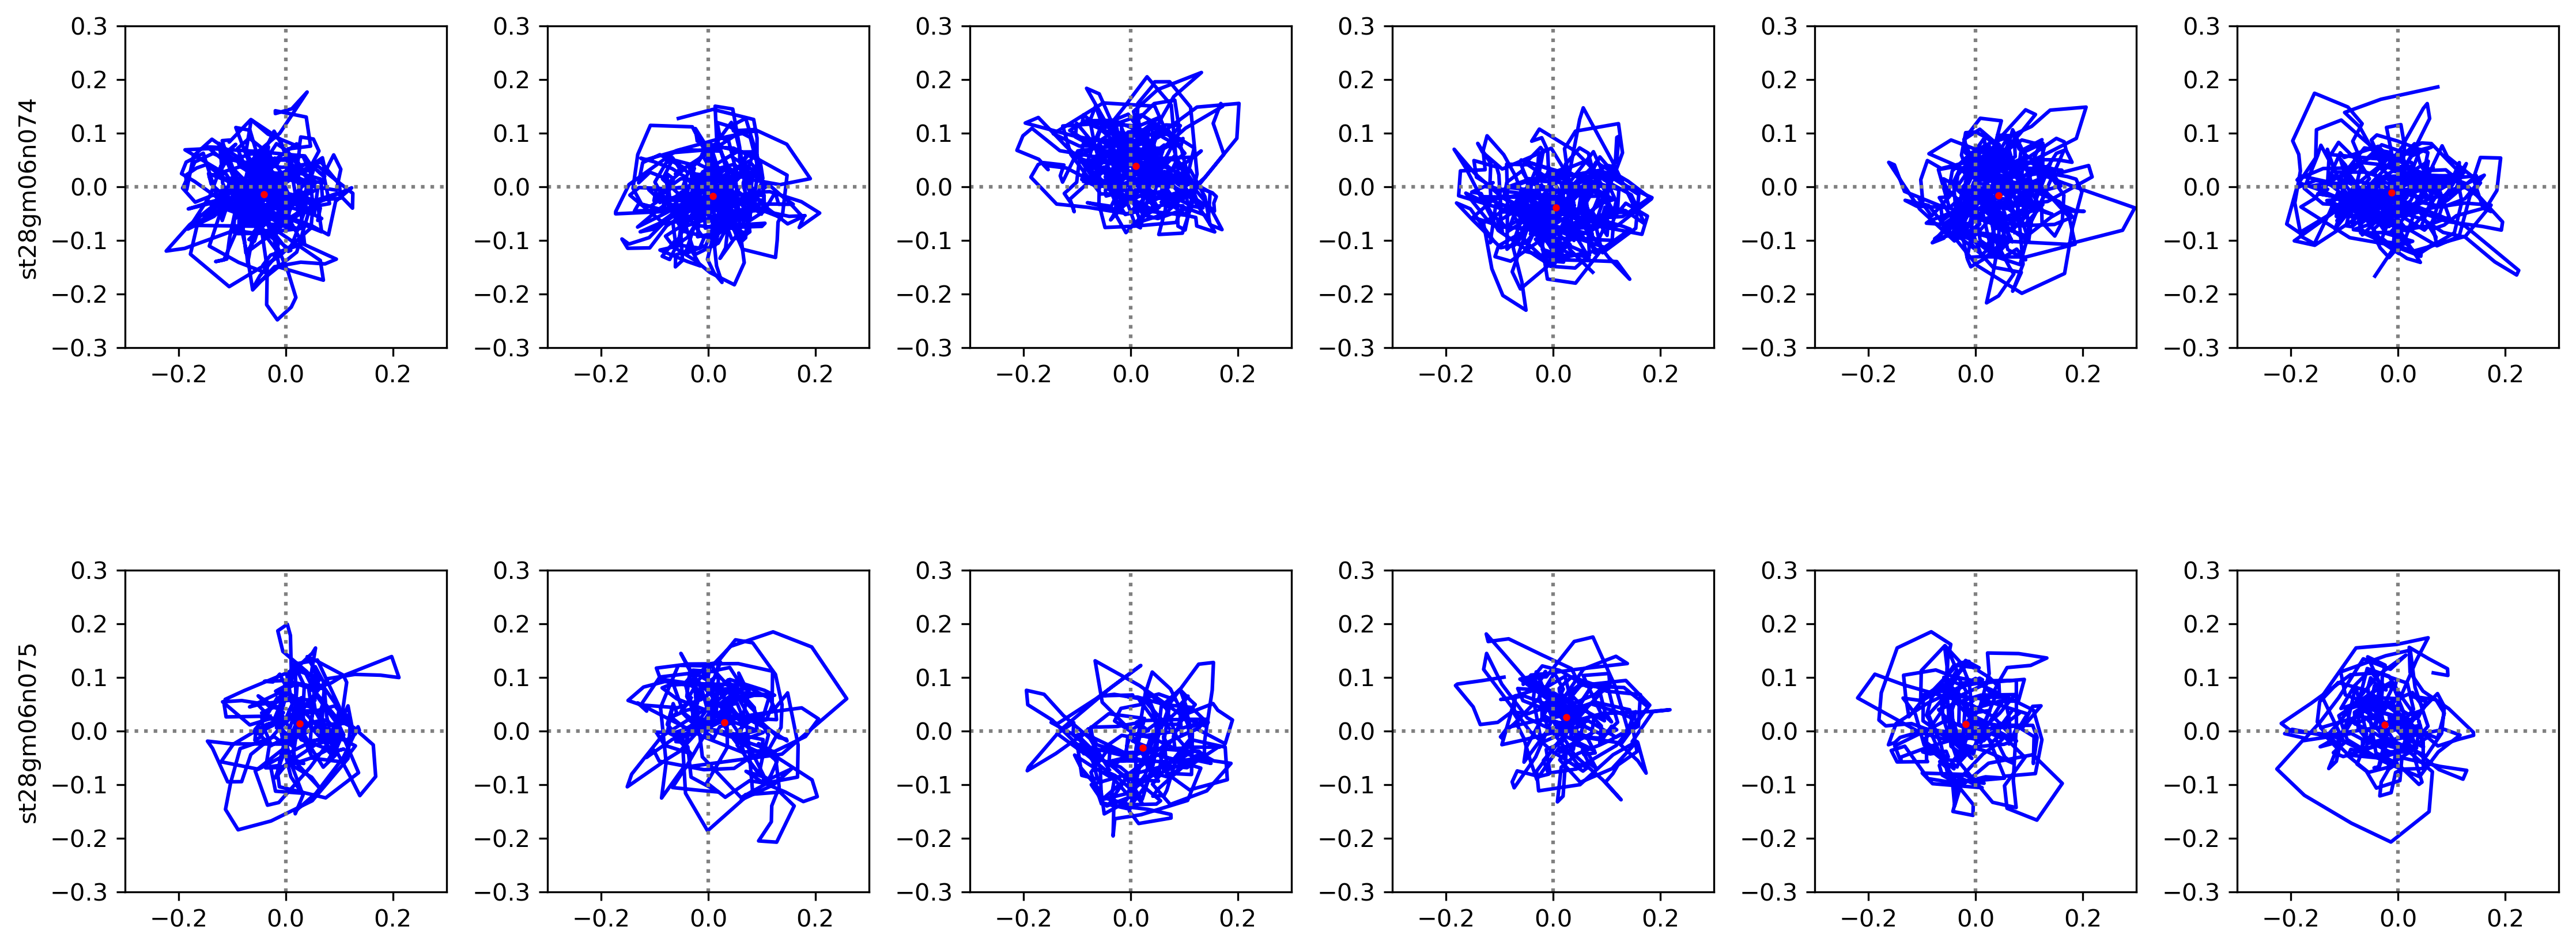

In [4]:
# Load all LOS and 3 nodust-models' photocentre coords
# and plot pcR(time) and statistics of these
# First for each model
# and then all combined, should be the same
import numpy as np
import analyze_r3d_functions as a3d
import matplotlib.pyplot as plt

modelnames = [
    #'st28gm06n052_timedep_nodust',
    'st28gm06n074_nodust',
    'st28gm06n075_nodust',
]
Nmodels = len(modelnames)
Rstar = 1.65

angles,snapshots,coordinatelist = a3d.load_photocentre_file(
    file_path=f'../r3dresults/{modelnames[0]}/photocentre_02um.dat'
)
Nangles = len(angles)
Nsnapshots = len(snapshots)

# Initiate figure
fig,ax = plt.subplots(
    Nmodels,Nangles,
    dpi=300,
    figsize = (15,7)
)
boxsize = 0.3

for nmodel,modelname in enumerate(modelnames):

    angles,snapshots,coordinatelist = a3d.load_photocentre_file(
        file_path=f'../r3dresults/{modelname}/photocentre_02um.dat'
    )
    print(modelname)


    # Extract all R(t) for all angles and save in a list
    for nangle,angle in enumerate(angles):
 
        pcX = coordinatelist[nangle][:,0]/Rstar
        pcY = coordinatelist[nangle][:,1]/Rstar
        pcR = coordinatelist[nangle][:,2]/Rstar

        pcX_average = np.mean(pcX)
        pcY_average = np.mean(pcY)
        pcR_average = np.mean(pcR)

        # Print average coordinates for all angles
        print(f'  {angle}: {pcX_average:.5f} , {pcY_average:.5f}  ({pcR_average:.5f})')
        
        # Plot x-y for all
        ax[nmodel,nangle].plot(
            pcX,
            pcY,
            'b'
        )
        # Add some labels and plot settings
        ax[nmodel,nangle].set_xlim([-boxsize,boxsize])
        ax[nmodel,nangle].set_ylim([-boxsize,boxsize])
        if nangle == 0:
            ax[nmodel,nangle].set_ylabel(
                modelname.split('_')[0]
            )
        if nmodel == 2:
            ax[nmodel,nangle].set_xlabel(
                angle
            )
        ax[nmodel,nangle].set(
            aspect='equal'
        )
        # Add lines to show central axis
        ax[nmodel,nangle].plot(
            [0,0],[-boxsize,boxsize],
            ':',color='grey'
        )
        ax[nmodel,nangle].plot(
            [-boxsize,boxsize],[0,0],
            ':',color='grey'
        )
        # Plot average coordinates as well
        ax[nmodel,nangle].plot(
            pcX_average,pcY_average,'r.',markersize=4
        )

    # Print empty line
    print()
fig.tight_layout()
fig.savefig('../r3dplots/all_photocentre_XYcoords_angles.pdf')




st28gm06n074_nodust : 0.08977602693602695 pm 0.046991148831079556 , Nsnaps: 450
st28gm06n074_nospikes : 0.1596184603510185 pm 0.16773105645617034 , Nsnaps: 301


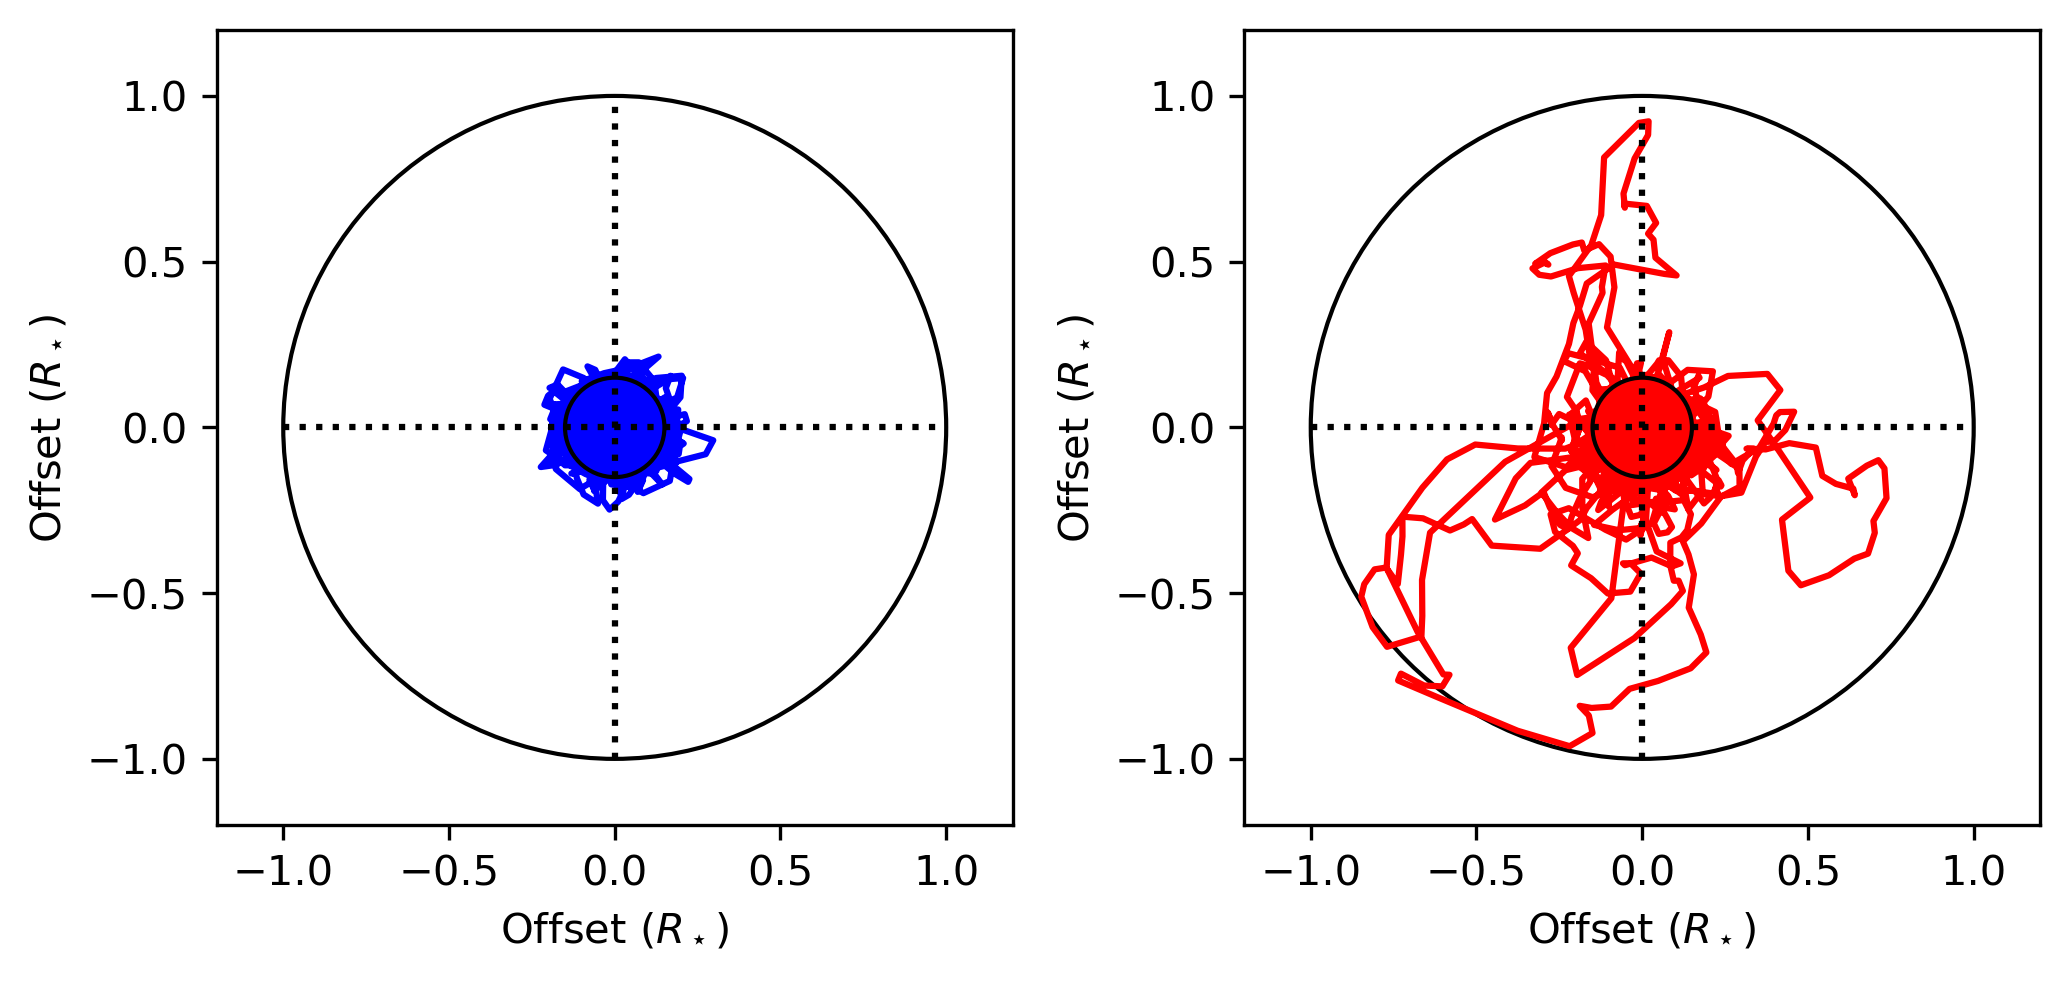

In [5]:
# Image for RS-2025R-proposal
# Left nodust of 074
# Right 074 with dust
# In terms of stellar radius
import matplotlib.pyplot as plt
import numpy as np
import analyze_r3d_functions as a3d


# Set some settings
models = [
    'st28gm06n074_nodust',
    'st28gm06n074_nospikes'
]
Rstar = 1.65

# Initiage figure
# Initiate figure
fig,ax = plt.subplots(
    1,2,
    dpi=300,
    figsize = (7,3.5)
)
pccolour = ['b','r']

for nmodel,model in enumerate(models):

    angles,snapshots,coordinatelist = a3d.load_photocentre_file(
        file_path=f'../r3dresults/{model}/photocentre_02um.dat'
    )
    Nangles = len(angles)
    Nsnapshots = len(snapshots)

    # Put all PCcoords in one array regardless of observed angle
    # With X,Y,R
    all_coords = np.zeros((Nangles*Nsnapshots,3))

    # Loop through angles and fill that array
    for nangle in range(Nangles):
        all_coords[nangle*Nsnapshots:(nangle+1)*Nsnapshots,0] = coordinatelist[nangle][:,0]/Rstar
        all_coords[nangle*Nsnapshots:(nangle+1)*Nsnapshots,1] = coordinatelist[nangle][:,1]/Rstar
        all_coords[nangle*Nsnapshots:(nangle+1)*Nsnapshots,2] = coordinatelist[nangle][:,2]/Rstar


    # Plot all photocentre coords
    ax[nmodel].plot(
        all_coords[:,0],all_coords[:,1],color=pccolour[nmodel]
    )
    # Plot circle for stars size and 15% av star
    ax[nmodel].add_patch(plt.Circle(
        (0,0),1,color='k',fill=False
    ))
    ax[nmodel].add_patch(plt.Circle(
        (0,0),0.15,color='k',fill=False,zorder=10
    ))
    # Plot middle lines
    ax[nmodel].plot(
        [-1,1],[0,0],'k:'
    )
    ax[nmodel].plot(
        [0,0],[-1,1],'k:'
    )
    ax[nmodel].set(
        xlim=(-1.2,1.2),
        ylim=(-1.2,1.2),
        xlabel=r'Offset ($R_\star$)',
        ylabel=r'Offset ($R_\star$)',
        aspect='equal'
    )
    # Extract statistics for each model, average and std for each
    # to write in the proposal
    print(f'{model} : {np.average(all_coords[:,2])} pm {np.std(all_coords[:,2])} , Nsnaps: {Nsnapshots}')


fig.tight_layout()
#fig.savefig('../r3dplots/074_photocentre_nodust_nospikes.pdf',dpi=300)


st28gm06n052_timedep_nodust
  i000_phi000 X: -0.01016 +- 0.05890
          Y: 0.02600 +- 0.08016
          R: 0.09301 +- 0.04499
  i090_phi000 X: -0.00069 +- 0.06245
          Y: 0.01122 +- 0.07528
          R: 0.08944 +- 0.04115
  i090_phi090 X: -0.01336 +- 0.07066
          Y: 0.03091 +- 0.06994
          R: 0.09350 +- 0.04771
  i090_phi270 X: 0.00451 +- 0.07108
          Y: -0.02347 +- 0.06256
          R: 0.08415 +- 0.04956
  i180_phi000 X: 0.02490 +- 0.06093
          Y: 0.00752 +- 0.08023
          R: 0.09268 +- 0.04729
  i270_phi000 X: -0.00876 +- 0.06683
          Y: 0.02380 +- 0.07789
          R: 0.09396 +- 0.04845

st28gm06n074_nodust
  i000_phi000 X: -0.04070 +- 0.06493
          Y: -0.01423 +- 0.06447
          R: 0.08919 +- 0.04771
  i090_phi000 X: 0.00874 +- 0.06812
          Y: -0.01724 +- 0.05895
          R: 0.08127 +- 0.04341
  i090_phi090 X: 0.01011 +- 0.07327
          Y: 0.03927 +- 0.05907
          R: 0.09050 +- 0.04808
  i090_phi270 X: 0.00545 +- 0.07569
       

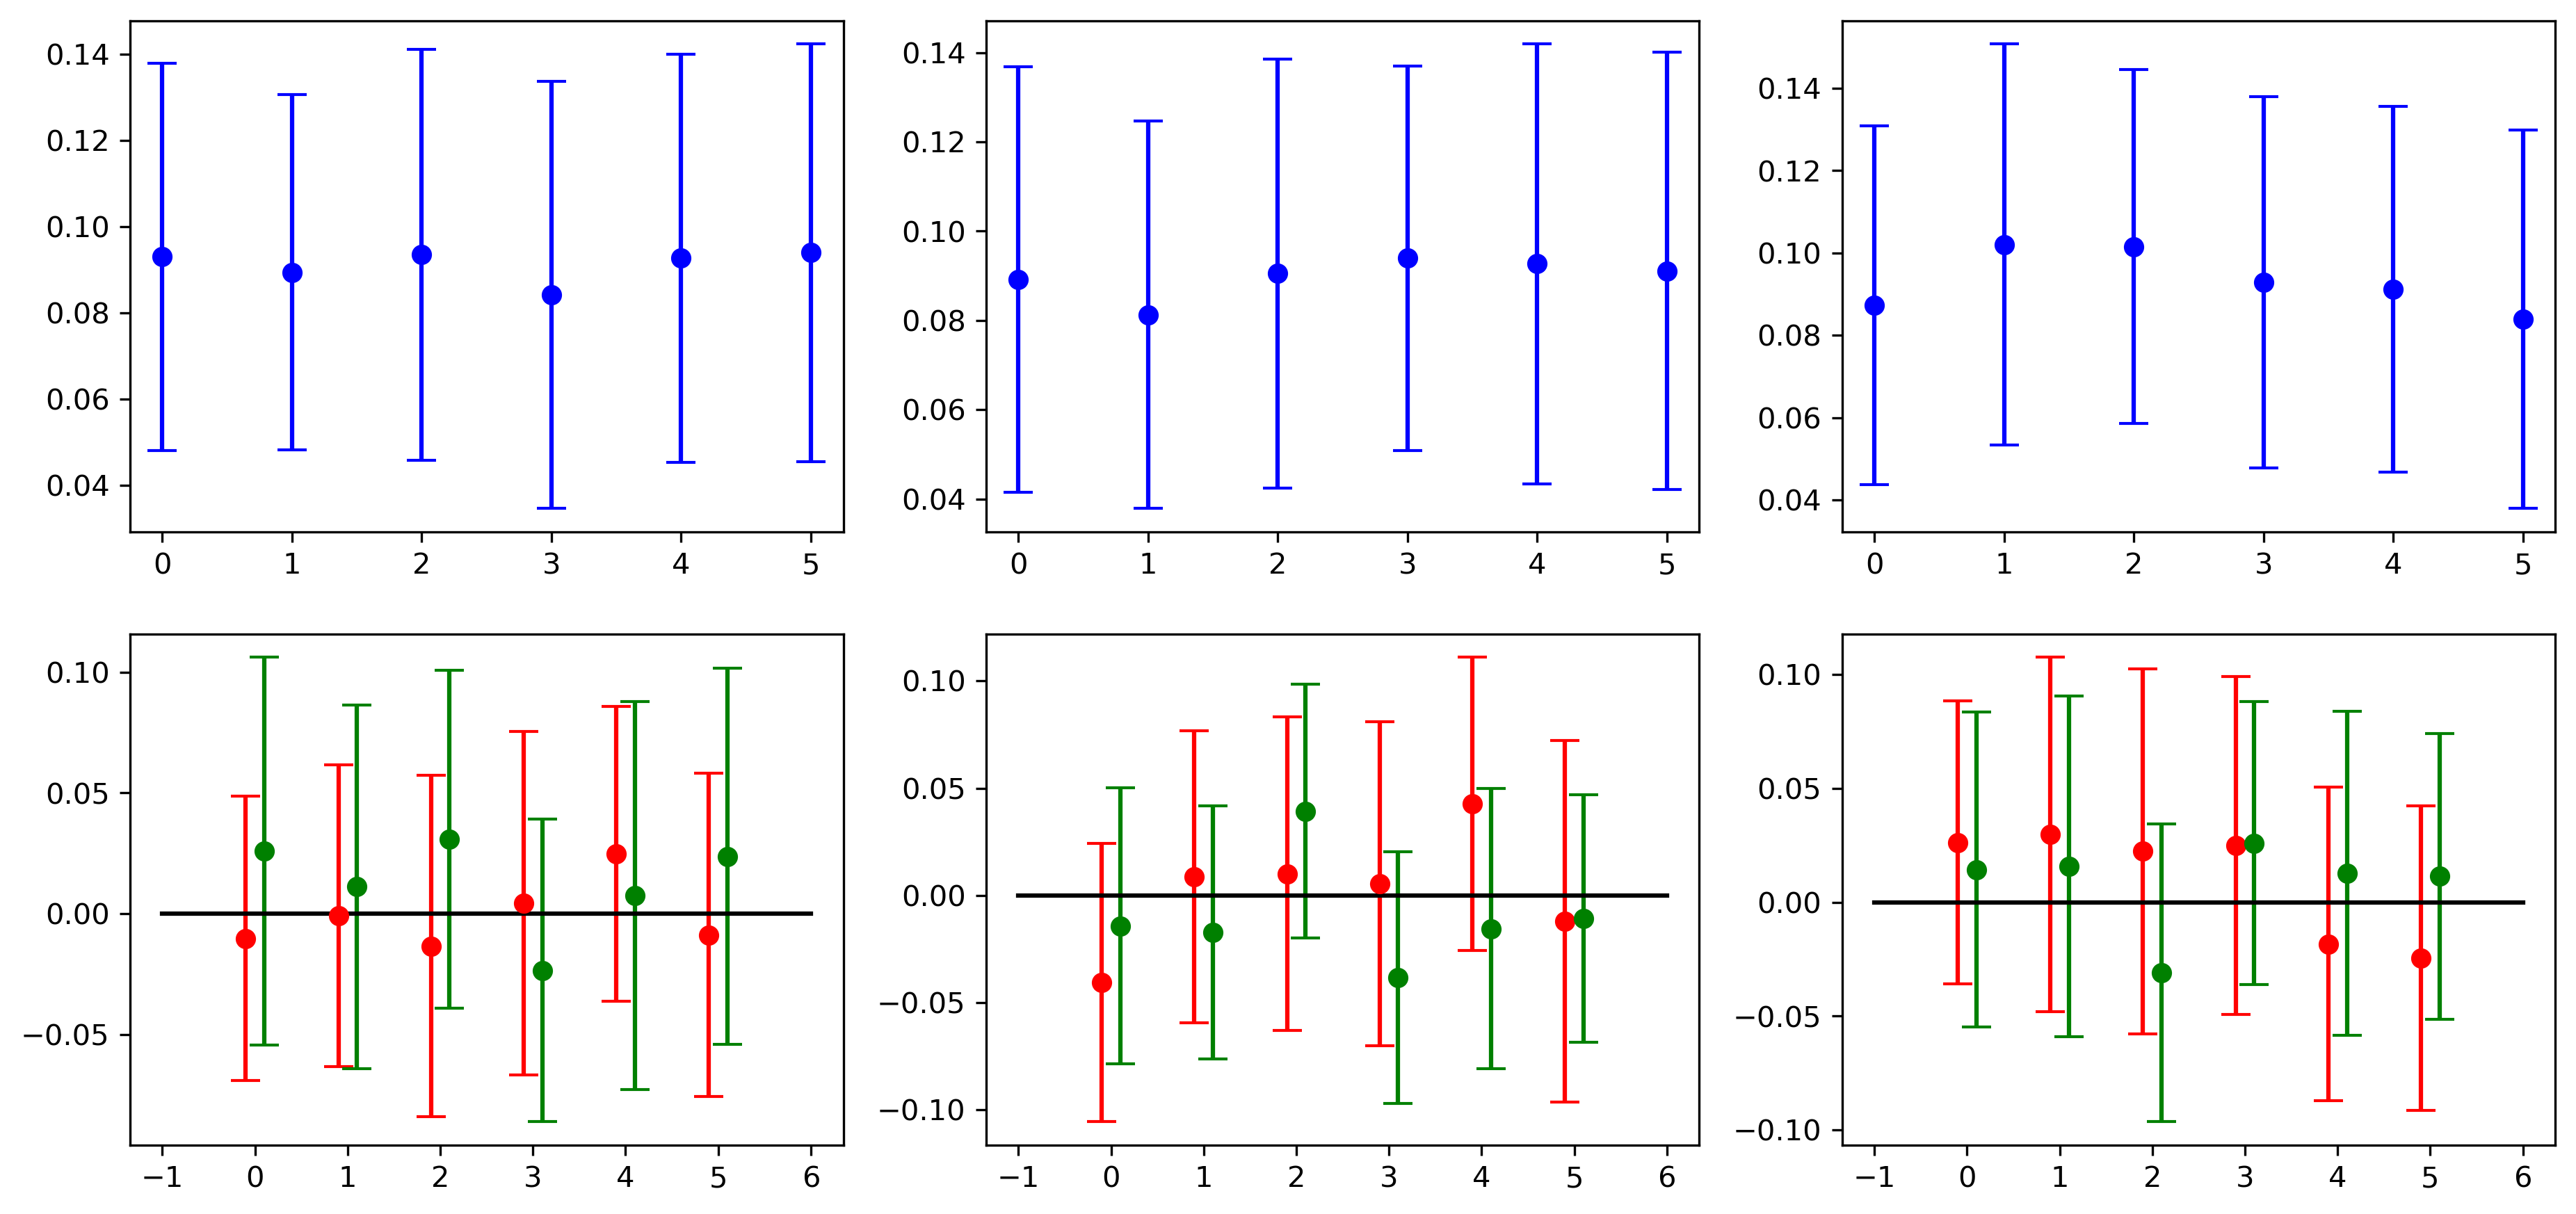

In [ ]:
# TODO
# print average XY-coords for each LOS,  plusminus std
# Plot average XY and R vs LOS
#
# Save these numbers somewhere


import numpy as np
import analyze_r3d_functions as a3d
import matplotlib.pyplot as plt



modelnames = [
    'st28gm06n052_timedep_nodust',
    'st28gm06n074_nodust',
    'st28gm06n075_nodust',
]
Nmodels = len(modelnames)
Rstar = 1.65

angles,snapshots,coordinatelist = a3d.load_photocentre_file(
    file_path=f'../r3dresults/{modelnames[0]}/photocentre_02um.dat'
)
Nangles = len(angles)
Nsnapshots = len(snapshots)

# Initiate figure
fig,ax = plt.subplots(
    2,Nmodels,
    dpi=300,
    figsize = (15,7)
)
boxsize = 0.3

for nmodel,modelname in enumerate(modelnames):

    angles,snapshots,coordinatelist = a3d.load_photocentre_file(
        file_path=f'../r3dresults/{modelname}/photocentre_02um.dat'
    )
    print(modelname)


    # Extract all pc(t) for all angles and save in a list
    for nangle,angle in enumerate(angles):
 
        pcX = coordinatelist[nangle][:,0]/Rstar
        pcY = coordinatelist[nangle][:,1]/Rstar
        pcR = coordinatelist[nangle][:,2]/Rstar

        pcX_average = np.mean(pcX)
        pcY_average = np.mean(pcY)
        pcR_average = np.mean(pcR)

        pcX_std = np.std(pcX)
        pcY_std = np.std(pcY)
        pcR_std = np.std(pcR)


        # Print average coordinates for all angles
        print(f'  {angle} X: {pcX_average:.5f} +- {pcX_std:.5f}')
        print(f'          Y: {pcY_average:.5f} +- {pcY_std:.5f}')
        print(f'          R: {pcR_average:.5f} +- {pcR_std:.5f}')

        # Plot LOS-variations of R
        ax[0,nmodel].errorbar(
            nangle,pcR_average,yerr=pcR_std,
            color='b',fmt='o',capsize=5
        )
        # Plot LOS-variations of X&Y
        ax[1,nmodel].errorbar(
            nangle-0.1,pcX_average,yerr=pcX_std,
            color='r',fmt='o',capsize=5
        )
        ax[1,nmodel].errorbar(
            nangle+0.1,pcY_average,yerr=pcY_std,
            color='g',fmt='o',capsize=5
        )
    # And a zero-line
    ax[1,nmodel].plot(
        [-1,6],[0,0],'k'
    )



    # Print empty line
    print()




## Tests on GAIA data

In [2]:
# Load and test to extract photocentre on observed AGB stars
